In [22]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import xgboost as xgb
from scipy.optimize import minimize
import warnings, os, time
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

In [23]:
sales      = pd.read_csv(f"../data/processed/sales.csv", parse_dates=["Date"])
promotions = pd.read_csv(f"../data/processed/promotions.csv",
                             parse_dates=["start_date", "end_date"])
web        = pd.read_csv(f"../data/processed/web_traffic.csv", parse_dates=["date"])
sample_sub = pd.read_csv(f"../data/processed/sample_submission.csv", parse_dates=["Date"])

print(f"Train rows: {len(sales):,} ({sales['Date'].min().date()} => {sales['Date'].max().date()})")
print(f"Test rows: {len(sample_sub):,} ({sample_sub['Date'].min().date()} => {sample_sub['Date'].max().date()})")
print(f"Promotions: {len(promotions):,}")
print(f"Web traffic: {len(web):,}")
sales.head()

Train rows: 3,833 (2012-07-04 => 2022-12-31)
Test rows: 548 (2023-01-01 => 2024-07-01)
Promotions: 50
Web traffic: 3,652


,Date,Revenue,COGS,is_holiday,log_Revenue,log_COGS
0,2012-07-04,5123547.94,3982991.19,0,15.449358,15.197544
1,2012-07-05,2751773.45,2150580.23,0,14.827757,14.581249
2,2012-07-06,3054029.42,2517632.84,0,14.931973,14.738830
3,2012-07-07,2667930.94,2108246.62,0,14.796814,14.561368
4,2012-07-08,2360851.90,1808622.79,0,14.674534,14.408077


## Feature Engineering

In [24]:
def build_features(df: pd.DataFrame,
                   promotions: pd.DataFrame,
                   web: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("Date").reset_index(drop=True).copy()

    base_date = df["Date"].min()
    df["time_step"] = (df["Date"] - base_date).dt.days.astype(int)

    df["dow"]        = df["Date"].dt.dayofweek
    df["month"]      = df["Date"].dt.month
    df["dom"]        = df["Date"].dt.day
    df["woy"]        = df["Date"].dt.isocalendar().week.astype(int)
    df["quarter"]    = df["Date"].dt.quarter
    df["is_weekend"] = df["dow"].isin([5, 6]).astype(int)
    df["year"]       = df["Date"].dt.year
    df["year_norm"]  = (df["year"] - df["year"].min()) / max(df["year"].nunique(), 1)

    df["dow_sin"]   = np.sin(2 * np.pi * df["dow"] / 7.0)
    df["dow_cos"]   = np.cos(2 * np.pi * df["dow"] / 7.0)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12.0)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12.0)

    for period in [365.25, 30.5]:
        period_name = str(period).replace(".", "_")
        for k in [1, 2, 3]:
            angle = 2 * np.pi * k * df["time_step"] / period
            df[f"fourier_sin_p{period_name}_k{k}"] = np.sin(angle)
            df[f"fourier_cos_p{period_name}_k{k}"] = np.cos(angle)

    tet_dates = pd.to_datetime([
        "2012-01-23", "2013-02-10", "2014-01-31", "2015-02-19", "2016-02-08",
        "2017-01-28", "2018-02-16", "2019-02-05", "2020-01-25", "2021-02-12",
        "2022-02-01", "2023-01-22", "2024-02-10", "2025-01-29", "2026-02-17"
    ])

    years = sorted(df["Date"].dt.year.unique().tolist())
    mega_sale_dates = []
    for y in range(min(years) - 1, max(years) + 2):
        for m in range(1, 13):
            mega_sale_dates.append(pd.Timestamp(year=y, month=m, day=m))
    mega_sale_dates = pd.to_datetime(mega_sale_dates)
    mega_sale_all = pd.DatetimeIndex(sorted(set(mega_sale_dates.tolist() + tet_dates.tolist())))

    def days_to_next_event(ts: pd.Timestamp, events: pd.DatetimeIndex) -> int:
        future_events = events[events >= ts]
        if len(future_events) == 0:
            return int((events.max() - ts).days)
        return int((future_events.min() - ts).days)

    df["days_to_tet"] = df["Date"].apply(lambda x: min(abs((x - t).days) for t in tet_dates)).clip(upper=60)
    df["days_to_next_mega_sale"] = df["Date"].apply(lambda x: days_to_next_event(x, mega_sale_all)).clip(upper=120)
    df["is_mega_sale_day"] = df["Date"].isin(mega_sale_all).astype(int)

    df["pre_tet_7d"] = df["Date"].apply(lambda x: int(any(0 < (t - x).days <= 7 for t in tet_dates)))
    df["pre_tet_14d"] = df["Date"].apply(lambda x: int(any(7 < (t - x).days <= 14 for t in tet_dates)))
    df["pre_tet_30d"] = df["Date"].apply(lambda x: int(any(14 < (t - x).days <= 30 for t in tet_dates)))
    df["on_tet"] = df["Date"].apply(lambda x: int(any(abs((x - t).days) <= 2 for t in tet_dates)))
    df["post_tet"] = df["Date"].apply(lambda x: int(any(0 < (x - t).days <= 7 for t in tet_dates)))

    fixed_holidays = []
    for y in range(min(years) - 1, max(years) + 2):
        fixed_holidays += [f"{y}-01-01", f"{y}-04-30", f"{y}-05-01", f"{y}-09-02"]

    gioto = [
        "2012-03-31", "2013-04-19", "2014-04-09", "2015-04-28", "2016-04-16",
        "2017-04-06", "2018-04-25", "2019-04-14", "2020-04-02", "2021-04-21",
        "2022-04-10", "2023-04-29", "2024-04-18", "2025-04-07", "2026-03-26"
    ]
    all_holidays = pd.to_datetime(fixed_holidays + gioto)
    df["is_holiday"] = df["Date"].apply(lambda x: int(min(abs((x - h).days) for h in all_holidays) <= 3))

    df["promo_count"] = 0
    for _, row in promotions.iterrows():
        mask = (df["Date"] >= row["start_date"]) & (df["Date"] <= row["end_date"])
        df.loc[mask, "promo_count"] += 1

    df["promo_active"] = (df["promo_count"] > 0).astype(int)
    df["promo_intensity"] = df["promo_count"].clip(upper=5)
    df["post_promo"] = ((df["promo_active"].shift(1).fillna(0) == 1) & (df["promo_active"] == 0)).astype(int)
    df["promo_x_weekend"] = df["promo_intensity"] * df["is_weekend"]

    daily_web = web.groupby("date")["sessions"].sum().reset_index()
    df = df.merge(daily_web, left_on="Date", right_on="date", how="left").drop(columns=["date"])
    df["sessions"] = df["sessions"].fillna(df["sessions"].median())

    roll30_sess = df["sessions"].shift(1).rolling(30).mean()
    df["sessions_lag7"] = df["sessions"].shift(7)
    df["sessions_lag14"] = df["sessions"].shift(14)
    df["sessions_roll7_mean"] = df["sessions"].shift(1).rolling(7).mean()
    df["sessions_vs_avg"] = (df["sessions"] / roll30_sess).replace([np.inf, -np.inf], np.nan).fillna(1.0)
    df["sessions_spike"] = (df["sessions_vs_avg"] > 1.5).astype(int)

    rev = df["Revenue"]
    cogs = df["COGS"]

    for lag in [1, 2, 3, 7, 14, 21, 28, 30, 60, 90, 365]:
        df[f"rev_lag_{lag}"] = rev.shift(lag)

    for span in [7, 14, 30]:
        df[f"rev_ewm{span}"] = rev.shift(1).ewm(span=span, adjust=False).mean()

    for w in [7, 14, 30, 90]:
        df[f"rev_roll{w}_mean"] = rev.shift(1).rolling(w).mean()
        df[f"rev_roll{w}_std"] = rev.shift(1).rolling(w).std()
        df[f"rev_roll{w}_max"] = rev.shift(1).rolling(w).max()
        df[f"rev_roll{w}_min"] = rev.shift(1).rolling(w).min()

    df["rev_yoy_lag365"] = rev.shift(365)
    df["rev_yoy_ratio"] = (rev.shift(1) / rev.shift(366).replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)

    for lag in [1, 7, 30, 365]:
        df[f"cogs_lag_{lag}"] = cogs.shift(lag)
    df["cogs_roll7_mean"] = cogs.shift(1).rolling(7).mean()
    df["cogs_roll30_mean"] = cogs.shift(1).rolling(30).mean()

    df["rev_cogs_ratio_lag1"] = (rev.shift(1) / cogs.shift(1).replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
    df["lag_7_revenue_cogs_ratio"] = (rev.shift(7) / cogs.shift(7).replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
    df["lag_30_revenue_cogs_ratio"] = (rev.shift(30) / cogs.shift(30).replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
    df["lag_7_revenue_minus_cogs"] = rev.shift(7) - cogs.shift(7)
    df["lag_30_revenue_minus_cogs"] = rev.shift(30) - cogs.shift(30)

    return df

print("build_features")

build_features


In [25]:
df_feat = build_features(sales.copy(), promotions, web)
EXCLUDE = {"Date", "Revenue", "COGS", "log_Revenue", "log_COGS",
           "sessions", "promo_count", "promo_active"}
feature_cols = [c for c in df_feat.columns if c not in EXCLUDE]

print(f"Shape:{df_feat.shape}")
print(f"Total features: {len(feature_cols)}")
print(f"\nFeatures list:")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {f}")

Shape:(3833, 93)
Total features: 85

Features list:
   1. is_holiday
   2. time_step
   3. dow
   4. month
   5. dom
   6. woy
   7. quarter
   8. is_weekend
   9. year
  10. year_norm
  11. dow_sin
  12. dow_cos
  13. month_sin
  14. month_cos
  15. fourier_sin_p365_25_k1
  16. fourier_cos_p365_25_k1
  17. fourier_sin_p365_25_k2
  18. fourier_cos_p365_25_k2
  19. fourier_sin_p365_25_k3
  20. fourier_cos_p365_25_k3
  21. fourier_sin_p30_5_k1
  22. fourier_cos_p30_5_k1
  23. fourier_sin_p30_5_k2
  24. fourier_cos_p30_5_k2
  25. fourier_sin_p30_5_k3
  26. fourier_cos_p30_5_k3
  27. days_to_tet
  28. days_to_next_mega_sale
  29. is_mega_sale_day
  30. pre_tet_7d
  31. pre_tet_14d
  32. pre_tet_30d
  33. on_tet
  34. post_tet
  35. promo_intensity
  36. post_promo
  37. promo_x_weekend
  38. sessions_lag7
  39. sessions_lag14
  40. sessions_roll7_mean
  41. sessions_vs_avg
  42. sessions_spike
  43. rev_lag_1
  44. rev_lag_2
  45. rev_lag_3
  46. rev_lag_7
  47. rev_lag_14
  48. rev_lag_21

In [26]:
def get_lgb_params(target="Revenue"):
    return dict(
        n_estimators      = 3000,
        learning_rate     = 0.02,
        num_leaves        = 63,
        max_depth         = -1,
        min_child_samples = 20,
        feature_fraction  = 0.8,
        bagging_fraction  = 0.8,
        bagging_freq      = 5,
        reg_alpha         = 0.1,
        reg_lambda        = 0.2,
        random_state      = SEED,
        n_jobs            = -1,
        verbose           = -1,
    )

def get_xgb_params():
    return dict(
        n_estimators     = 2000,
        learning_rate    = 0.03,
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        random_state     = SEED,
        verbosity        = 0,
    )

def walk_forward_cv(df_train, feature_cols, target="Revenue", n_splits=5, min_train_days=365):
    df_train = df_train.dropna(subset=feature_cols+[target]).reset_index(drop=True)
    n = len(df_train)
    fold_size = (n - min_train_days) // n_splits
    oof_lgb  = np.zeros(n)
    oof_xgb  = np.zeros(n)
    oof_mask = np.zeros(n, dtype=bool)
    best_iters = []
    for i in range(n_splits):
        cut     = min_train_days + i * fold_size
        val_end = cut + fold_size if i < n_splits-1 else n
        X_tr, y_tr   = df_train.iloc[:cut][feature_cols], df_train.iloc[:cut][target]
        X_val, y_val = df_train.iloc[cut:val_end][feature_cols], df_train.iloc[cut:val_end][target]
        # LightGBM with early stopping
        m_lgb = lgb.LGBMRegressor(**get_lgb_params())
        m_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        best_iters.append(m_lgb.best_iteration_)
        # XGBoost
        m_xgb = xgb.XGBRegressor(**get_xgb_params())
        m_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        p_lgb = m_lgb.predict(X_val)
        p_xgb = m_xgb.predict(X_val)
        mae_lgb = mean_absolute_error(y_val, p_lgb)
        mae_xgb = mean_absolute_error(y_val, p_xgb)
        print(f"  Fold {i+1} | LGB MAE={mae_lgb:,.0f} | XGB MAE={mae_xgb:,.0f} | best_iter={best_iters[-1]}")
        oof_lgb[cut:val_end] = p_lgb
        oof_xgb[cut:val_end] = p_xgb
        oof_mask[cut:val_end] = True
    avg_iter = int(np.mean(best_iters))
    y_oof = df_train[target].values[oof_mask]
    print(f"OOF LGB MAE={mean_absolute_error(y_oof, oof_lgb[oof_mask]):,.0f}")
    print(f"OOF XGB MAE={mean_absolute_error(y_oof, oof_xgb[oof_mask]):,.0f}")
    print(f"Avg best_iteration: {avg_iter}")
    return oof_lgb, oof_xgb, oof_mask, avg_iter

print("walk_forward_cv")

walk_forward_cv


In [27]:
print("Walk-forward CV — REVENUE")
oof_lgb_r, oof_xgb_r, mask_r, best_iter_r = walk_forward_cv(df_feat, feature_cols, "Revenue")
print("Walk-forward CV — COGS")
oof_lgb_c, oof_xgb_c, mask_c, best_iter_c = walk_forward_cv(df_feat, feature_cols, "COGS")


Walk-forward CV — REVENUE
  Fold 1 | LGB MAE=885,536 | XGB MAE=860,244 | best_iter=330
  Fold 2 | LGB MAE=969,316 | XGB MAE=980,663 | best_iter=270
  Fold 3 | LGB MAE=865,186 | XGB MAE=908,166 | best_iter=305
  Fold 4 | LGB MAE=526,181 | XGB MAE=562,832 | best_iter=250
  Fold 5 | LGB MAE=540,668 | XGB MAE=540,806 | best_iter=570
OOF LGB MAE=757,238
OOF XGB MAE=770,394
Avg best_iteration: 345
Walk-forward CV — COGS
  Fold 1 | LGB MAE=727,209 | XGB MAE=758,450 | best_iter=157
  Fold 2 | LGB MAE=841,923 | XGB MAE=869,373 | best_iter=300
  Fold 3 | LGB MAE=794,359 | XGB MAE=838,630 | best_iter=265
  Fold 4 | LGB MAE=456,380 | XGB MAE=503,876 | best_iter=275
  Fold 5 | LGB MAE=479,594 | XGB MAE=477,320 | best_iter=320
OOF LGB MAE=659,777
OOF XGB MAE=689,393
Avg best_iteration: 263


In [28]:
def find_weights_oof(oof_lgb, oof_xgb, y_true, mask):
    p_l, p_x, y = oof_lgb[mask], oof_xgb[mask], y_true[mask]
    def obj(w):
        w_n = np.exp(w) / np.exp(w).sum()
        return mean_absolute_error(y, w_n[0]*p_l + w_n[1]*p_x)  # Dùng MAE vì Kaggle dùng MAE
    res = minimize(obj, [0.0, 0.0], method="Nelder-Mead", options={"maxiter":5000})
    w = np.exp(res.x) / np.exp(res.x).sum()
    print(f"  Weights: LGB={w[0]:.4f} | XGB={w[1]:.4f} | OOF MAE={res.fun:,.0f}")
    return float(w[0]), float(w[1])
df_clean = df_feat.dropna(subset=feature_cols+["Revenue","COGS"]).reset_index(drop=True)
y_all = df_clean[["Revenue","COGS"]].values
print("Revenue weights:")
w_lgb_r, w_xgb_r = find_weights_oof(oof_lgb_r, oof_xgb_r, df_clean["Revenue"].values, mask_r)
print("COGS weights:")
w_lgb_c, w_xgb_c = find_weights_oof(oof_lgb_c, oof_xgb_c, df_clean["COGS"].values, mask_c)


Revenue weights:
  Weights: LGB=0.6720 | XGB=0.3280 | OOF MAE=751,954
COGS weights:
  Weights: LGB=1.0000 | XGB=0.0000 | OOF MAE=659,777


In [29]:
def train_final(df_full, feature_cols, target, best_iter):
    df_full = df_full.dropna(subset=feature_cols+[target]).copy()
    X, y = df_full[feature_cols], df_full[target]
    print(f"  Training {target} on {len(X):,} samples | n_estimators(LGB)={best_iter}")
    lgb_p = get_lgb_params()
    lgb_p["n_estimators"] = best_iter
    m_lgb = lgb.LGBMRegressor(**lgb_p)
    m_lgb.fit(X, y, callbacks=[lgb.log_evaluation(-1)])
    m_xgb = xgb.XGBRegressor(**get_xgb_params())
    m_xgb.fit(X, y)
    return m_lgb, m_xgb
lgb_rev, xgb_rev   = train_final(df_feat, feature_cols, "Revenue", best_iter_r)
lgb_cogs, xgb_cogs = train_final(df_feat, feature_cols, "COGS", best_iter_c)

  Training Revenue on 3,467 samples | n_estimators(LGB)=345
  Training COGS on 3,467 samples | n_estimators(LGB)=263


In [30]:
def recursive_forecast(lgb_r, xgb_r, lgb_c, xgb_c,
                       df_train, sample_sub, promotions, web, feature_cols,
                       w_lr, w_xr, w_lc, w_xc, train_medians):
    test_stub = sample_sub[["Date"]].copy()
    test_stub["Revenue"] = np.nan
    test_stub["COGS"] = np.nan
    df_all = pd.concat([df_train[["Date","Revenue","COGS"]], test_stub], ignore_index=True)
    df_all = build_features(df_all, promotions, web)
    print(f"Combined shape: {df_all.shape}")

    all_rev = df_all["Revenue"].values.astype(float).copy()
    all_cogs = df_all["COGS"].values.astype(float).copy()
    train_n = len(df_train)

    col_idx = {c: i for i, c in enumerate(feature_cols)}
    
    test_X = df_all.iloc[train_n:][feature_cols].values.astype(float).copy()
    
    rev_lags  = [(f"rev_lag_{l}", l) for l in [1,2,3,7,14,21,28,30,60,90,365]]
    cogs_lags = [(f"cogs_lag_{l}", l) for l in [1,7,30,365]]
    t0 = time.time()
    for i in range(len(sample_sub)):
        idx = train_n + i  

        for col_name, lag in rev_lags:
            if col_name in col_idx and idx >= lag:
                val = all_rev[idx - lag]
                if not np.isnan(val):
                    test_X[i, col_idx[col_name]] = val
        
        for w in [7, 14, 30, 90]:
            start = max(0, idx - w)
            vals = all_rev[start:idx]
            valid = vals[~np.isnan(vals)]
            if len(valid) > 0:
                if f"rev_roll{w}_mean" in col_idx:
                    test_X[i, col_idx[f"rev_roll{w}_mean"]] = np.mean(valid)
                if f"rev_roll{w}_std" in col_idx:
                    test_X[i, col_idx[f"rev_roll{w}_std"]] = np.std(valid, ddof=1) if len(valid)>1 else 0
                if f"rev_roll{w}_max" in col_idx:
                    test_X[i, col_idx[f"rev_roll{w}_max"]] = np.max(valid)
                if f"rev_roll{w}_min" in col_idx:
                    test_X[i, col_idx[f"rev_roll{w}_min"]] = np.min(valid)
        
        for span in [7, 14, 30]:
            cn = f"rev_ewm{span}"
            if cn in col_idx:
                vals = all_rev[max(0, idx-span*3):idx]
                valid = vals[~np.isnan(vals)]
                if len(valid) > 0:
                    alpha = 2.0 / (span + 1)
                    ewm = valid[0]
                    for v in valid[1:]:
                        ewm = alpha * v + (1 - alpha) * ewm
                    test_X[i, col_idx[cn]] = ewm
        
        if "rev_yoy_lag365" in col_idx and idx >= 365:
            v = all_rev[idx-365]
            if not np.isnan(v):
                test_X[i, col_idx["rev_yoy_lag365"]] = v
        if "rev_yoy_ratio" in col_idx and idx >= 366:
            prev, prev_yoy = all_rev[idx-1], all_rev[idx-366]
            if not np.isnan(prev) and not np.isnan(prev_yoy) and prev_yoy != 0:
                test_X[i, col_idx["rev_yoy_ratio"]] = np.clip(prev/prev_yoy, 0.1, 10)
        
        for col_name, lag in cogs_lags:
            if col_name in col_idx and idx >= lag:
                val = all_cogs[idx - lag]
                if not np.isnan(val):
                    test_X[i, col_idx[col_name]] = val
        for w, cn in [(7,"cogs_roll7_mean"),(30,"cogs_roll30_mean")]:
            if cn in col_idx:
                vals = all_cogs[max(0,idx-w):idx]
                valid = vals[~np.isnan(vals)]
                if len(valid) > 0:
                    test_X[i, col_idx[cn]] = np.mean(valid)
        
        if "rev_cogs_ratio_lag1" in col_idx and idx >= 1:
            pr, pc = all_rev[idx-1], all_cogs[idx-1]
            if not np.isnan(pr) and not np.isnan(pc) and pc != 0:
                test_X[i, col_idx["rev_cogs_ratio_lag1"]] = np.clip(pr/pc, 0.5, 5)
        
        for j in range(len(feature_cols)):
            if np.isnan(test_X[i, j]):
                test_X[i, j] = train_medians.iloc[j]
        
        X_row = pd.DataFrame([test_X[i]], columns=feature_cols)
        r = w_lr * lgb_r.predict(X_row)[0] + w_xr * xgb_r.predict(X_row)[0]
        c = w_lc * lgb_c.predict(X_row)[0] + w_xc * xgb_c.predict(X_row)[0]
        all_rev[idx]  = max(r, 0)
        all_cogs[idx] = max(c, 0)
        if (i+1) % 100 == 0:
            print(f"Day {i+1}/548 | Rev={all_rev[idx]:,.0f} | COGS={all_cogs[idx]:,.0f} | {time.time()-t0:.1f}s")
    print(f"Recursive forecast done in {time.time()-t0:.1f}s")
    return all_rev[train_n:], all_cogs[train_n:]

train_medians = df_clean[feature_cols].median()
print("\nRECURSIVE FORECASTING:")
pred_rev, pred_cog = recursive_forecast(
    lgb_rev, xgb_rev, lgb_cogs, xgb_cogs,
    sales, sample_sub, promotions, web, feature_cols,
    w_lgb_r, w_xgb_r, w_lgb_c, w_xgb_c, train_medians
)
pred_rev = np.round(np.clip(pred_rev, 0, None), 2)
pred_cog = np.round(np.clip(pred_cog, 0, None), 2)
print(f"\nRevenue: min={pred_rev.min():,.0f} | mean={pred_rev.mean():,.0f} | max={pred_rev.max():,.0f}")
print(f"COGS: min={pred_cog.min():,.0f} | mean={pred_cog.mean():,.0f} | max={pred_cog.max():,.0f}")



RECURSIVE FORECASTING:
Combined shape: (4381, 91)
Day 100/548 | Rev=4,455,453 | COGS=3,491,442 | 3.0s
Day 200/548 | Rev=3,877,895 | COGS=3,432,946 | 5.1s
Day 300/548 | Rev=3,768,146 | COGS=3,099,771 | 7.4s
Day 400/548 | Rev=1,987,248 | COGS=1,848,819 | 9.8s
Day 500/548 | Rev=4,841,592 | COGS=4,252,633 | 12.2s
Recursive forecast done in 15.2s

Revenue: min=838,035 | mean=3,901,690 | max=10,415,839
COGS: min=822,260 | mean=3,283,994 | max=9,113,184


In [31]:
def make_pipeline(model_type: str = "lgb") -> Pipeline:
    if model_type == "lgb":
        model = lgb.LGBMRegressor(
            n_estimators=1200,
            learning_rate=0.03,
            num_leaves=63,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        )
    elif model_type == "ridge":
        model = Ridge(alpha=8.0, random_state=SEED)
    else:
        raise ValueError("model_type phải là 'lgb' hoặc 'ridge'")

    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model),
    ])

def make_direct_dataset(df_feat: pd.DataFrame,
                        feature_cols: list,
                        target_col: str,
                        horizon: int) -> tuple[pd.DataFrame, pd.Series]:
    work = df_feat.copy()
    work[f"target_h{horizon}"] = work[target_col].shift(-horizon)
    train_block = work.dropna(subset=feature_cols + [f"target_h{horizon}"])
    X = train_block[feature_cols]
    y = train_block[f"target_h{horizon}"]
    return X, y


def train_direct_multistep_models(df_feat: pd.DataFrame,
                                  feature_cols: list,
                                  target_col: str,
                                  horizon_blocks: list[int] = [7, 30, 90, 180, 548]) -> dict:
    models = {}
    for h in horizon_blocks:
        X_h, y_h = make_direct_dataset(df_feat, feature_cols, target_col, horizon=h)
        pipe_lgb = make_pipeline("lgb")
        pipe_ridge = make_pipeline("ridge")

        pipe_lgb.fit(X_h, y_h)
        pipe_ridge.fit(X_h, y_h)

        models[h] = {
            "lgb": pipe_lgb,
            "ridge": pipe_ridge,
        }
        print(f"[{target_col}] Trained horizon={h:>3} | samples={len(X_h):,}")

    return models

def pick_horizon_for_day(day_idx_1_based: int,
                         horizon_blocks: list[int]) -> int:
    for h in sorted(horizon_blocks):
        if day_idx_1_based <= h:
            return h
    return max(horizon_blocks)


def direct_multistep_predict(df_feat_full: pd.DataFrame,
                             sample_sub: pd.DataFrame,
                             feature_cols: list,
                             models: dict,
                             horizon_blocks: list[int] = [7, 30, 90, 180, 548],
                             ensemble_weight_lgb: float = 0.7,
                             ensemble_weight_ridge: float = 0.3) -> np.ndarray:
    test_start = sample_sub["Date"].min()
    X_test = df_feat_full[df_feat_full["Date"] >= test_start][feature_cols].copy()
    preds = []

    for i in range(len(X_test)):
        day_idx = i + 1
        h = pick_horizon_for_day(day_idx, horizon_blocks)

        x_row = X_test.iloc[[i]]
        p_lgb = models[h]["lgb"].predict(x_row)[0]
        p_ridge = models[h]["ridge"].predict(x_row)[0]
        p = ensemble_weight_lgb * p_lgb + ensemble_weight_ridge * p_ridge
        preds.append(max(p, 0.0))

    return np.array(preds)


# ============================
# Ví dụ cách dùng cho Revenue/COGS
# ============================
# df_feat_all = build_features(pd.concat([...]), promotions, web)
# rev_models = train_direct_multistep_models(df_feat, feature_cols, "Revenue")
# cogs_models = train_direct_multistep_models(df_feat, feature_cols, "COGS")
#
# pred_rev = direct_multistep_predict(df_feat_all, sample_sub, feature_cols, rev_models)
# pred_cog = direct_multistep_predict(df_feat_all, sample_sub, feature_cols, cogs_models)
#
# Gợi ý tinh chỉnh ensemble:
# - Near-term (1-30 ngày): tăng weight LGB (vd 0.8/0.2)
# - Long-term (>180 ngày): tăng weight Ridge (vd 0.55/0.45)
# để đường dự báo mượt hơn và bám trend tốt hơn.


In [32]:
sub = sample_sub.copy()
sub["Revenue"] = pred_rev
sub["COGS"] = pred_cog
assert len(sub) == 548, f"ERROR: {len(sub)} rows"
out_path = f"../submissions/submission_v6.csv"
sub.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Rows: {len(sub)}")
print(sub.head(10))

Saved: ../submissions/submission_v6.csv
Rows: 548
        Date     Revenue        COGS
0 2023-01-01  2136596.77  1972150.23
1 2023-01-02  1953390.77  1662953.84
2 2023-01-03  1460467.93  1308095.72
3 2023-01-04   838035.30   822259.65
4 2023-01-05  1155216.03  1057238.59
5 2023-01-06  1115185.73  1071689.32
6 2023-01-07  1315793.69  1261868.44
7 2023-01-08  1636444.47  1461712.20
8 2023-01-09  1902315.58  1604908.93
9 2023-01-10  2187441.04  1887810.01


## (Hyperparameter Tuning: Fail) + SHAP

Saved: report/figures/


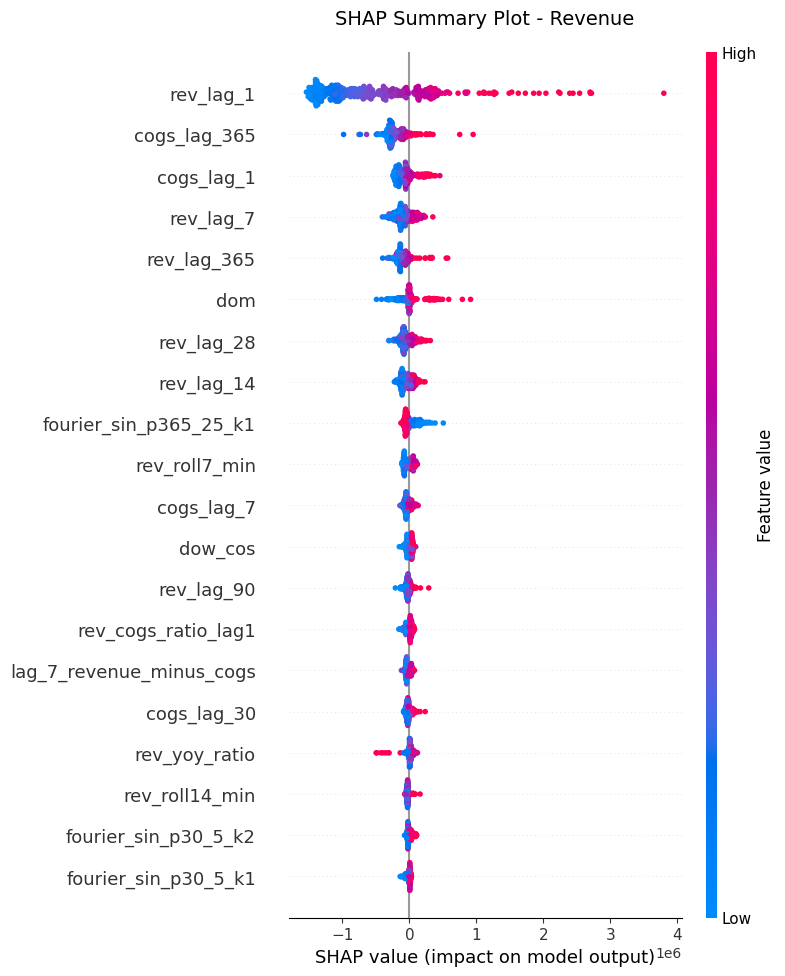

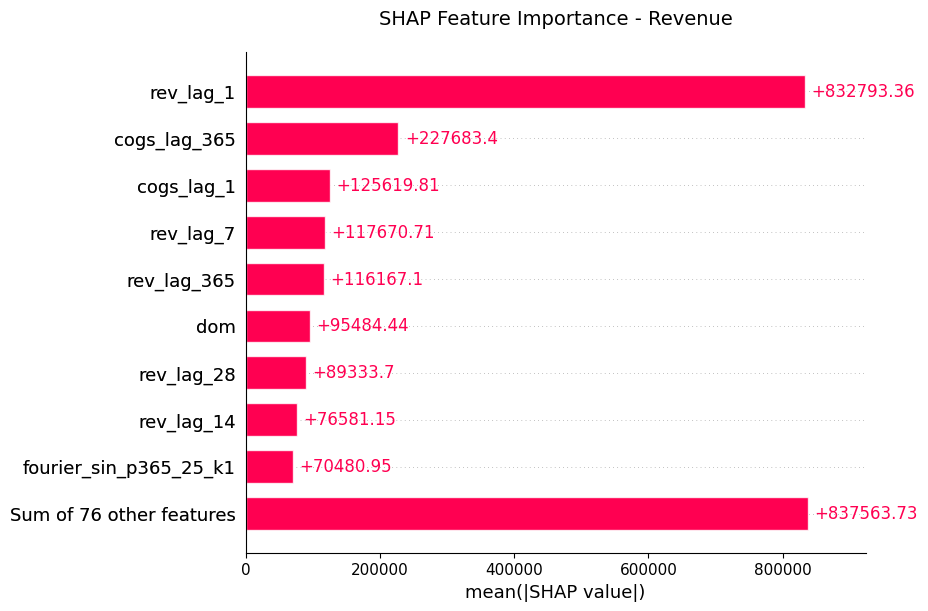

In [33]:
import shap
import matplotlib.pyplot as plt

if "lgb_rev" not in dir() or "df_feat" not in dir() or "feature_cols" not in dir():
    print("Skip SHAP: cần chạy train_final() trước")
else:
    model_to_explain = lgb_rev
    df_clean_shap = df_feat.dropna(subset=feature_cols + ["Revenue"])  # đổi tên tránh ghi đè
    X_shap = df_clean_shap[feature_cols].tail(365)

    explainer = shap.TreeExplainer(model_to_explain)
    shap_values = explainer.shap_values(X_shap)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_shap, show=False)
    plt.title("SHAP Summary Plot - Revenue", fontsize=14, pad=20)
    plt.savefig("../report/figures/shap_summary.png", dpi=150, bbox_inches="tight")

    plt.figure(figsize=(10, 8))
    shap.plots.bar(explainer(X_shap), show=False)
    plt.title("SHAP Feature Importance - Revenue", fontsize=14, pad=20)
    plt.savefig("../report/figures/feature_importance.png", dpi=150, bbox_inches="tight")

    print("Saved: report/figures/")

In [34]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def weighted_objective(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    score = 0.4 * mae + 0.4 * rmse + 0.2 * (1 - r2)
    return score, mae, rmse, r2

In [35]:
sales      = pd.read_csv("../data/processed/sales.csv", parse_dates=["Date"])
promotions = pd.read_csv("../data/processed/promotions.csv", parse_dates=["start_date", "end_date"])
web        = pd.read_csv("../data/processed/web_traffic.csv", parse_dates=["date"])
sample_sub = pd.read_csv("../data/processed/sample_submission.csv", parse_dates=["Date"])

df_feat = build_features(sales.copy(), promotions, web)

In [36]:
H = 548
INPUT_SIZE = 1096
MAX_STEPS = 500

futr_vars_requested = [
    "is_holiday", "days_to_tet", "promo_active", "dow", "month",
    "day_of_year", "week_of_year", "is_weekend"
]

if "df_train" in globals() and "df_test" in globals():
    base_train = df_train.copy()
    base_test = df_test.copy()
    base_train["ds"] = pd.to_datetime(base_train["ds"])
    base_test["ds"] = pd.to_datetime(base_test["ds"])
else:
    base_train = pd.DataFrame({
        "unique_id": "Revenue",
        "ds": pd.to_datetime(df_feat["Date"]),
        "y": df_feat["Revenue"].astype(float),
    })
    for c in df_feat.columns:
        if c not in base_train.columns:
            base_train[c] = df_feat[c].values

    if "df_test" in globals():
        _df_test_local = df_test.copy()
    else:
        test_stub = sample_sub[["Date"]].copy()
        test_stub["Revenue"] = np.nan
        test_stub["COGS"] = np.nan
        combined = pd.concat(
            [sales[["Date", "Revenue", "COGS"]], test_stub],
            ignore_index=True
        )
        combined_feat = build_features(combined, promotions, web)
        _df_test_local = combined_feat[combined_feat["Date"] >= sample_sub["Date"].min()].copy()

    base_test = pd.DataFrame({
        "unique_id": "Revenue",
        "ds": pd.to_datetime(_df_test_local["Date"]),
    })
    for c in _df_test_local.columns:
        if c not in base_test.columns:
            base_test[c] = _df_test_local[c].values

for dfx in [base_train, base_test]:
    if "day_of_year" not in dfx.columns:
        dfx["day_of_year"] = dfx["ds"].dt.dayofyear
    if "week_of_year" not in dfx.columns:
        dfx["week_of_year"] = dfx["ds"].dt.isocalendar().week.astype(int)
    if "dow" not in dfx.columns:
        dfx["dow"] = dfx["ds"].dt.dayofweek
    if "month" not in dfx.columns:
        dfx["month"] = dfx["ds"].dt.month
    if "is_weekend" not in dfx.columns:
        dfx["is_weekend"] = dfx["dow"].isin([5, 6]).astype(int)

futr_vars = [c for c in futr_vars_requested if c in base_train.columns and c in base_test.columns]
missing_vars = [c for c in futr_vars_requested if c not in futr_vars]
if missing_vars:
    print("Loai bo bien khong co cho test/train:", missing_vars)

df_nhits_train = base_train[["unique_id", "ds", "y"] + futr_vars].copy()
df_nhits_train = df_nhits_train.sort_values(["unique_id", "ds"]).reset_index(drop=True)

df_nhits_futr = base_test[["unique_id", "ds"] + futr_vars].copy()
df_nhits_futr = df_nhits_futr.sort_values(["unique_id", "ds"]).reset_index(drop=True)

n_series = df_nhits_train["unique_id"].nunique()
expected_futr_rows = n_series * H
assert len(df_nhits_futr) == expected_futr_rows, f"Sai số dòng futr_df: expected={expected_futr_rows}, got={len(df_nhits_futr)}"

print("futr_vars su dung:", futr_vars)
print("df_nhits_train shape:", df_nhits_train.shape)
print("df_nhits_futr  shape:", df_nhits_futr.shape)
display(df_nhits_train.head())

futr_vars su dung: ['is_holiday', 'days_to_tet', 'promo_active', 'dow', 'month', 'day_of_year', 'week_of_year', 'is_weekend']
df_nhits_train shape: (3833, 11)
df_nhits_futr  shape: (548, 10)


,unique_id,ds,y,is_holiday,days_to_tet,promo_active,dow,month,day_of_year,week_of_year,is_weekend
0,Revenue,2012-07-04,5123547.94,0,60,0,2,7,186,27,0
1,Revenue,2012-07-05,2751773.45,0,60,0,3,7,187,27,0
2,Revenue,2012-07-06,3054029.42,0,60,0,4,7,188,27,0
3,Revenue,2012-07-07,2667930.94,0,60,0,5,7,189,27,1
4,Revenue,2012-07-08,2360851.90,0,60,0,6,7,190,27,1


In [37]:
model_val = NHITS(
    h=H,
    input_size=INPUT_SIZE,
    futr_exog_list=futr_vars,
    max_steps=MAX_STEPS,
    early_stop_patience_steps=10,
    val_check_steps=50,
    scaler_type="standard",
    random_seed=SEED,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=False,
)

nf_val = NeuralForecast(models=[model_val], freq="D")
cv_nhits = nf_val.cross_validation(
    df=df_nhits_train,
    val_size=H,
    n_windows=1,
    step_size=H,
)

pred_col_val = [c for c in cv_nhits.columns if c not in ["unique_id", "ds", "y", "cutoff"]][0]
cv_eval = cv_nhits[["unique_id", "ds", "y", pred_col_val]].rename(columns={pred_col_val: "nhits_val_pred"})
nhits_val_mae = mean_absolute_error(cv_eval["y"], cv_eval["nhits_val_pred"])

model_full = NHITS(
    h=H,
    input_size=INPUT_SIZE,
    futr_exog_list=futr_vars,
    max_steps=MAX_STEPS,
    early_stop_patience_steps=10,
    val_check_steps=50,
    scaler_type="standard",
    random_seed=SEED,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=False,
)

nf_full = NeuralForecast(models=[model_full], freq="D")
nf_full.fit(df=df_nhits_train, val_size=H)
neural_fcst_test = nf_full.predict(futr_df=df_nhits_futr)

pred_col_test = [c for c in neural_fcst_test.columns if c not in ["unique_id", "ds"]][0]
neural_pred_test_df = neural_fcst_test[["unique_id", "ds", pred_col_test]].rename(columns={pred_col_test: "neural_pred"})
neural_pred_test_df = df_nhits_futr[["unique_id", "ds"]].merge(
    neural_pred_test_df, on=["unique_id", "ds"], how="left"
)

print(f"N-HiTS val MAE (last {H}): {nhits_val_mae:,.0f}")
print("Neural test prediction rows:", len(neural_pred_test_df))
display(neural_pred_test_df.head())

Seed set to 42


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 19.1 M | train | 0    
---------------------------------------------------------------
19.1 M    Trainable params
0         Non-trainable params
19.1 M    Total params
76.536    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops
`Trainer.fit` stopped: `max_steps=500` reached.
Trainer alrea

N-HiTS val MAE (last 548): 2,000,078
Neural test prediction rows: 548


,unique_id,ds,neural_pred
0,Revenue,2023-01-01,2145219.500
1,Revenue,2023-01-02,1731475.375
2,Revenue,2023-01-03,1091787.875
3,Revenue,2023-01-04,954779.000
4,Revenue,2023-01-05,1178786.125


In [38]:
if "oof_lgb_r" in globals() and "mask_r" in globals() and "df_clean" in globals():
    lgb_oof_mae = mean_absolute_error(df_clean["Revenue"].values[mask_r], oof_lgb_r[mask_r])
else:
    lgb_oof_mae = 757_000.0 

if all(v in globals() for v in ["df_feat", "feature_cols", "lgb_rev", "df_clean"]):
    val_key = cv_eval[["unique_id", "ds", "y"]].copy()
    val_key["Date"] = pd.to_datetime(val_key["ds"])

    lgb_src = df_feat[["Date"] + feature_cols].copy()
    lgb_val_df = val_key[["Date", "y"]].merge(lgb_src, on="Date", how="left")

    train_medians = df_clean[feature_cols].median()
    X_lgb_val = lgb_val_df[feature_cols].fillna(train_medians)
    lgb_val_pred = lgb_rev.predict(X_lgb_val)
else:
    raise ValueError("Thiếu biến từ pipeline LGB (df_feat/feature_cols/lgb_rev/df_clean) để tạo lgb_val_pred")

y_val = cv_eval["y"].values
nhits_val_pred = cv_eval["nhits_val_pred"].values

print(f"LGB OOF MAE baseline: {lgb_oof_mae:,.0f}")
print(f"N-HiTS val MAE      : {nhits_val_mae:,.0f}")

import numpy as np

# Grid dày hơn: bước 0.05 trên toàn bộ [0, 1]
candidate_weights = np.arange(0.0, 1.05, 0.05).tolist()

grid_rows = []
for w in candidate_weights:
    blend_val = w * nhits_val_pred + (1 - w) * lgb_val_pred
    blend_val = np.clip(blend_val, 0, None)  # thêm clip để tránh âm
    score, mae, rmse, r2 = weighted_objective(y_val, blend_val)
    grid_rows.append({
        "w_neural": round(w, 2),
        "w_lgb": round(1 - w, 2),
        "score": score,   # weighted_objective score — dùng để sort
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
    })

blend_grid = pd.DataFrame(grid_rows).sort_values("score").reset_index(drop=True)
best_row = blend_grid.iloc[0]
best_w_neural = float(best_row["w_neural"])
best_w_lgb    = float(best_row["w_lgb"])

print(f"Best blend: neural={best_w_neural:.2f} | lgb={best_w_lgb:.2f} | "
      f"MAE={best_row['mae']:,.0f} | RMSE={best_row['rmse']:,.0f} | "
      f"R2={best_row['r2']:.4f} | score={best_row['score']:,.0f}")
display(blend_grid.head(10))

LGB OOF MAE baseline: 757,238
N-HiTS val MAE      : 2,000,078
Best blend: neural=0.00 | lgb=1.00 | MAE=242,978 | RMSE=320,811 | R2=0.9573 | score=225,516


,w_neural,w_lgb,score,mae,rmse,r2
0,0.00,1.00,225515.562034,242978.075616,3.208108e+05,0.957328
1,0.05,0.95,246717.191266,265696.558418,3.510964e+05,0.948891
2,0.10,0.90,287924.379341,311918.889123,4.078920e+05,0.931018
3,0.15,0.85,344094.799295,378322.797785,4.819142e+05,0.903709
4,0.20,0.80,409598.754446,457547.596100,5.664492e+05,0.866964
5,0.25,0.75,480559.041866,543943.091103,6.574544e+05,0.820783
6,0.30,0.70,554962.146667,634819.025256,7.525862e+05,0.765166
7,0.35,0.65,631483.710972,728248.144649,8.504610e+05,0.700114
8,0.40,0.60,709467.485958,823455.379478,9.502131e+05,0.625640
9,0.45,0.55,788142.615012,919428.348476,1.050928e+06,0.542076


In [39]:
if "pred_rev" in globals() and len(np.asarray(pred_rev).reshape(-1)) == len(neural_pred_test_df):
    lgb_pred_test_arr = np.asarray(pred_rev).reshape(-1)
elif "lgb_pred_test" in globals() and len(np.asarray(lgb_pred_test).reshape(-1)) == len(neural_pred_test_df):
    lgb_pred_test_arr = np.asarray(lgb_pred_test).reshape(-1)
else:
    raise ValueError("Khong tim thay prediction Revenue cua LightGBM tren test (pred_rev/lgb_pred_test)")

final_rev_pred = best_w_neural * neural_pred_test_df["neural_pred"].values + best_w_lgb * lgb_pred_test_arr
final_rev_pred = np.clip(final_rev_pred, 0, None)

submission_blend = sample_sub[["Date"]].copy()
submission_blend["Revenue"] = np.round(final_rev_pred, 2)

if "pred_cog" in globals() and len(np.asarray(pred_cog).reshape(-1)) == len(submission_blend):
    submission_blend["COGS"] = np.round(np.asarray(pred_cog).reshape(-1), 2)
elif "pred_cogs" in globals() and len(np.asarray(pred_cogs).reshape(-1)) == len(submission_blend):
    submission_blend["COGS"] = np.round(np.asarray(pred_cogs).reshape(-1), 2)
elif "COGS" in sample_sub.columns:
    submission_blend["COGS"] = sample_sub["COGS"].values
else:
    submission_blend["COGS"] = 0.0

submission_blend = submission_blend[["Date", "Revenue", "COGS"]]
print("Submission blend shape:", submission_blend.shape)
print("\nFinal Revenue describe():")
print(pd.Series(submission_blend["Revenue"]).describe())
display(submission_blend.head())

Submission blend shape: (548, 3)

Final Revenue describe():
count    5.480000e+02
mean     3.901690e+06
std      1.492223e+06
min      8.380353e+05
25%      2.766335e+06
50%      3.756165e+06
75%      4.727357e+06
max      1.041584e+07
Name: Revenue, dtype: float64


,Date,Revenue,COGS
0,2023-01-01,2136596.77,1972150.23
1,2023-01-02,1953390.77,1662953.84
2,2023-01-03,1460467.93,1308095.72
3,2023-01-04,838035.30,822259.65
4,2023-01-05,1155216.03,1057238.59


In [40]:
# Lưu file submission blended
out_blend_path = "../submissions/submission_nhits_futr_blend.csv"
submission_blend.to_csv(out_blend_path, index=False)
print(f"Saved: {out_blend_path}")

Saved: ../submissions/submission_nhits_futr_blend.csv


In [41]:
print("Skip: dùng file ../submissions/submission_nhits_futr_blend.csv")

Skip: dùng file ../submissions/submission_nhits_futr_blend.csv


In [42]:
if "lgb_pred_test_arr" in globals():
    print("LightGBM predictions:")
    print(pd.Series(lgb_pred_test_arr).describe())
else:
    print("Chua co lgb_pred_test_arr")

if "neural_pred_test_df" in globals() and "neural_pred" in neural_pred_test_df.columns:
    print("\nN-HiTS predictions:")
    print(neural_pred_test_df["neural_pred"].describe())
else:
    print("\nChua co neural_pred_test_df")

if "df_nhits_train" in globals() and "y" in df_nhits_train.columns:
    print("\nActual y (train):")
    print(df_nhits_train["y"].describe())
else:
    print("\nChua co df_nhits_train")

LightGBM predictions:
count    5.480000e+02
mean     3.901690e+06
std      1.492223e+06
min      8.380353e+05
25%      2.766335e+06
50%      3.756165e+06
75%      4.727357e+06
max      1.041584e+07
dtype: float64

N-HiTS predictions:
count    5.480000e+02
mean     3.157680e+06
std      1.606915e+06
min      8.723300e+05
25%      1.926695e+06
50%      2.859330e+06
75%      4.049825e+06
max      1.057299e+07
Name: neural_pred, dtype: float64

Actual y (train):
count    3.833000e+03
mean     4.286584e+06
std      2.624840e+06
min      2.798139e+05
25%      2.471089e+06
50%      3.647304e+06
75%      5.350877e+06
max      2.090527e+07
Name: y, dtype: float64


In [43]:
if "submission_blend" in globals():
    print("NaN Revenue:", submission_blend["Revenue"].isna().sum())
    print("NaN COGS   :", submission_blend["COGS"].isna().sum())
    print("Revenue < 0:", (submission_blend["Revenue"] < 0).sum())
    print("COGS < 0   :", (submission_blend["COGS"] < 0).sum())
else:
    print("Chua co submission_blend")

NaN Revenue: 0
NaN COGS   : 0
Revenue < 0: 0
COGS < 0   : 0


In [44]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

if "y_val" in dir() and "lgb_val_pred" in dir() and "nhits_val_pred" in dir():
    print("Score LightGBM only:", mean_absolute_error(y_val, lgb_val_pred))
    print("Score Neural only  :", mean_absolute_error(y_val, nhits_val_pred))
elif "cv_eval" in dir() and "lgb_val_pred" in dir():
    print("Score LightGBM only:", mean_absolute_error(cv_eval["y"], lgb_val_pred))
    print("Score Neural only  :", mean_absolute_error(cv_eval["y"], cv_eval["nhits_val_pred"]))
else:
    print("Chua co du bien — chay cell BUOC 3+4 truoc")

Score LightGBM only: 242978.07561580912
Score Neural only  : 2000077.8780383212


In [45]:
if "submission_blend" in globals():
    print(submission_blend.head())
else:
    print("Chua co submission_blend")

        Date     Revenue        COGS
0 2023-01-01  2136596.77  1972150.23
1 2023-01-02  1953390.77  1662953.84
2 2023-01-03  1460467.93  1308095.72
3 2023-01-04   838035.30   822259.65
4 2023-01-05  1155216.03  1057238.59


In [46]:
rev_models  = train_direct_multistep_models(df_feat, feature_cols, "Revenue")
cogs_models = train_direct_multistep_models(df_feat, feature_cols, "COGS")

df_feat_all = build_features(
    pd.concat([sales[["Date","Revenue","COGS"]], 
               sample_sub[["Date"]].assign(Revenue=np.nan, COGS=np.nan)]),
    promotions, web
)

pred_rev_direct = direct_multistep_predict(df_feat_all, sample_sub, feature_cols, rev_models)
pred_cog_direct = direct_multistep_predict(df_feat_all, sample_sub, feature_cols, cogs_models)

pred_rev_direct = np.round(np.clip(pred_rev_direct, 0, None), 2)
pred_cog_direct = np.round(np.clip(pred_cog_direct, 0, None), 2)

sub_direct = sample_sub[["Date"]].copy()
sub_direct["Revenue"] = pred_rev_direct
sub_direct["COGS"]    = pred_cog_direct
sub_direct.to_csv("../submissions/submission_direct.csv", index=False)
print(sub_direct.describe())

[Revenue] Trained horizon=  7 | samples=3,460
[Revenue] Trained horizon= 30 | samples=3,437
[Revenue] Trained horizon= 90 | samples=3,377
[Revenue] Trained horizon=180 | samples=3,287
[Revenue] Trained horizon=548 | samples=2,919
[COGS] Trained horizon=  7 | samples=3,460
[COGS] Trained horizon= 30 | samples=3,437
[COGS] Trained horizon= 90 | samples=3,377
[COGS] Trained horizon=180 | samples=3,287
[COGS] Trained horizon=548 | samples=2,919
                      Date       Revenue          COGS
count                  548  5.480000e+02  5.480000e+02
mean   2023-10-01 12:00:00  1.791541e+06  1.784651e+06
min    2023-01-01 00:00:00  0.000000e+00  0.000000e+00
25%    2023-05-17 18:00:00  2.136633e+05  7.897501e+05
50%    2023-10-01 12:00:00  1.091302e+06  1.468616e+06
75%    2024-02-15 06:00:00  2.909601e+06  2.550195e+06
max    2024-07-01 00:00:00  8.136931e+06  6.087791e+06
std                    NaN  1.858692e+06  1.244209e+06
